### 1. Loading the Data

In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv('Dataset/combined_spam.csv')
df.sample(5)

,text,label
1507,v skint too but fancied few bevies.waz gona go...,ham
3410,k.i will send in &lt;#&gt; min:),ham
2077,that's y u haf 2 keep me busy...,ham
4557,we regret to inform u that the nhs has made a ...,ham
4207,i'm awake oh. what's up.,ham


In [3]:
df.shape

(10774, 2)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10774 entries, 0 to 10773
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   text    10774 non-null  str  
 1   label   10774 non-null  str  
dtypes: str(2)
memory usage: 8.6 MB


In [5]:
df.rename(columns={'text':'text', 'label':'target'}, inplace=True)
df.head()

,text,target
0,urgent! your mobile number has been awarded wi...,spam
1,how do you guys go to see movies on your side.,ham
2,"sorry,in meeting i'll call later",ham
3,you didn't have to tell me that...now i'm thin...,ham
4,kindly send some one to our flat before &lt;de...,ham


In [6]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()

In [7]:
df['target'] = encoder.fit_transform(df['target'])

In [8]:
df.head()

,text,target
0,urgent! your mobile number has been awarded wi...,1
1,how do you guys go to see movies on your side.,0
2,"sorry,in meeting i'll call later",0
3,you didn't have to tell me that...now i'm thin...,0
4,kindly send some one to our flat before &lt;de...,0


In [9]:
df.isnull().sum()

text      0
target    0
dtype: int64

In [10]:
df = df.dropna()

In [11]:
df.isnull().sum()

text      0
target    0
dtype: int64

In [12]:
df.duplicated().sum()

np.int64(2567)

In [13]:
df = df.drop_duplicates(keep='first')

In [14]:
df.duplicated().sum()

np.int64(0)

### 2. EDA

In [15]:
df.head()

,text,target
0,urgent! your mobile number has been awarded wi...,1
1,how do you guys go to see movies on your side.,0
2,"sorry,in meeting i'll call later",0
3,you didn't have to tell me that...now i'm thin...,0
4,kindly send some one to our flat before &lt;de...,0


In [16]:
df['target'].value_counts()

target
0    6581
1    1626
Name: count, dtype: int64

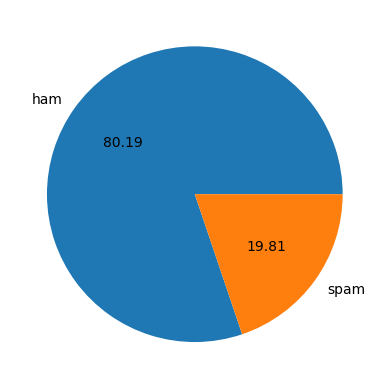

In [17]:
import matplotlib.pyplot as plt
plt.pie(df['target'].value_counts(), labels=['ham', 'spam'], autopct='%0.2f')
plt.show()

In [18]:
# Data is imbalanced

In [19]:
import nltk

In [20]:
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /home/preyumkr/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /home/preyumkr/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [21]:
df['num_characters'] = df['text'].apply(len)

In [22]:
df.head()

,text,target,num_characters
0,urgent! your mobile number has been awarded wi...,1,135
1,how do you guys go to see movies on your side.,0,46
2,"sorry,in meeting i'll call later",0,32
3,you didn't have to tell me that...now i'm thin...,0,89
4,kindly send some one to our flat before &lt;de...,0,62


In [23]:
# Number of Words
df['num_words'] = df['text'].apply(lambda x:len(nltk.word_tokenize(x)))

In [24]:
df.head()

,text,target,num_characters,num_words
0,urgent! your mobile number has been awarded wi...,1,135,25
1,how do you guys go to see movies on your side.,0,46,12
2,"sorry,in meeting i'll call later",0,32,8
3,you didn't have to tell me that...now i'm thin...,0,89,23
4,kindly send some one to our flat before &lt;de...,0,62,17


In [25]:
df['num_sentences'] = df['text'].apply(lambda x:len(nltk.sent_tokenize(x)))

In [26]:
df.head()

,text,target,num_characters,num_words,num_sentences
0,urgent! your mobile number has been awarded wi...,1,135,25,4
1,how do you guys go to see movies on your side.,0,46,12,1
2,"sorry,in meeting i'll call later",0,32,8,1
3,you didn't have to tell me that...now i'm thin...,0,89,23,2
4,kindly send some one to our flat before &lt;de...,0,62,17,1


In [27]:
df[['num_characters', 'num_words', 'num_sentences']].describe()

,num_characters,num_words,num_sentences
count,8207.000000,8207.000000,8207.000000
mean,1017.551237,219.621299,13.448763
std,1747.044057,367.924490,30.807664
min,2.000000,1.000000,1.000000
25%,104.000000,24.000000,2.000000
50%,466.000000,98.000000,7.000000
75%,1290.500000,282.000000,16.000000
max,43807.000000,8477.000000,1565.000000


In [28]:
# Decription of Ham Emails
df[df['target'] == 0][['num_characters', 'num_words', 'num_sentences']].describe()

,num_characters,num_words,num_sentences
count,6581.000000,6581.000000,6581.000000
mean,1032.062453,224.581371,13.268500
std,1721.580548,363.962851,32.084933
min,2.000000,1.000000,1.000000
25%,77.000000,18.000000,2.000000
50%,478.000000,100.000000,6.000000
75%,1389.000000,301.000000,16.000000
max,43807.000000,8477.000000,1565.000000


In [29]:
# Decription of Spam Emails
df[df['target'] == 1][['num_characters', 'num_words', 'num_sentences']].describe()

,num_characters,num_words,num_sentences
count,1626.000000,1626.000000,1626.000000
mean,958.819188,199.546125,14.178352
std,1845.908575,383.000619,24.975068
min,7.000000,2.000000,1.000000
25%,158.000000,33.000000,4.000000
50%,448.000000,90.000000,8.000000
75%,935.750000,208.750000,15.000000
max,27929.000000,6129.000000,438.000000


In [30]:
import seaborn as sns

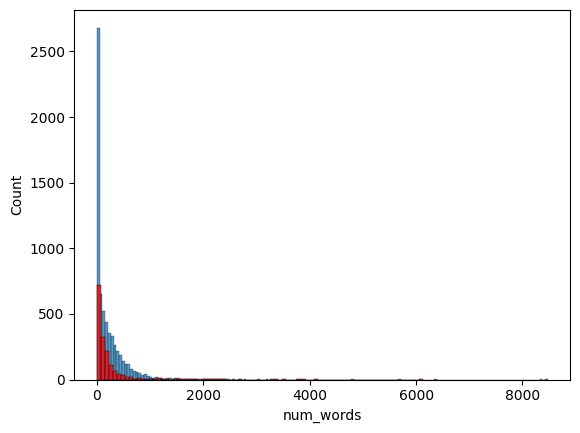

In [31]:
sns.histplot(df[df['target'] == 0]['num_words'])
sns.histplot(df[df['target'] == 1]['num_words'], color='red')
plt.show()

In [32]:
# Not any pattern, in tutorial, the spams had more characters/words/sentences than hams

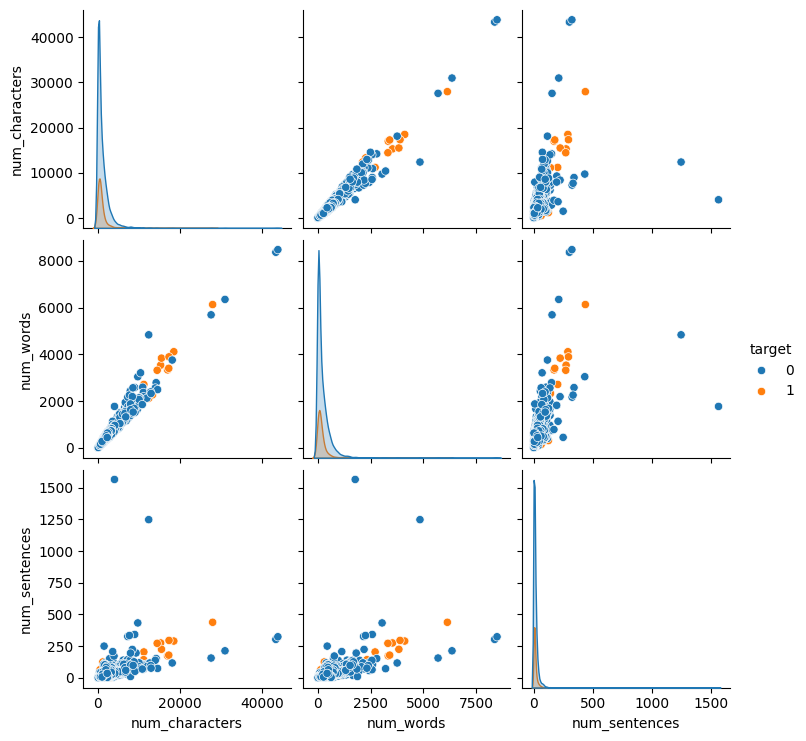

In [33]:
sns.pairplot(df, hue='target')
plt.show()

In [34]:
df.corr(numeric_only=True)

,target,num_characters,num_words,num_sentences
target,1.000000,-0.016711,-0.027123,0.011772
num_characters,-0.016711,1.000000,0.987367,0.624901
num_words,-0.027123,0.987367,1.000000,0.685065
num_sentences,0.011772,0.624901,0.685065,1.000000


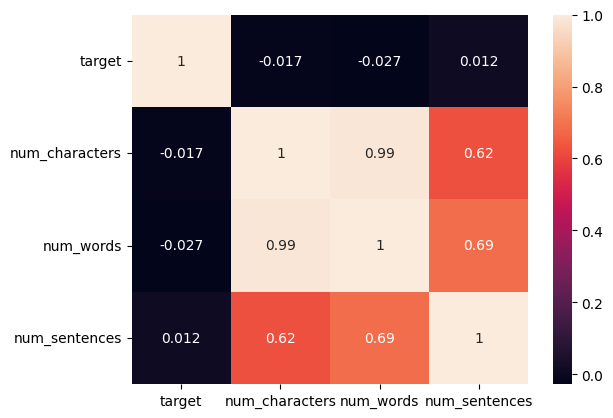

In [35]:
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()

### 3.Data Preprocessing

* Lower Case
* Tokenization
* Removing Special Characters
* Removing stop words and punctuation
* Stemming 

In [36]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     /home/preyumkr/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [37]:
from nltk.corpus import stopwords
# stopwords.words('english')
import string
string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [38]:
from nltk.stem.porter import PorterStemmer
ps = PorterStemmer()
ps.stem('dance')

'danc'

In [39]:
def transform_text(text):
    text = text.lower()
    text = nltk.word_tokenize(text)
    y = []
    for i in text:
        if i.isalnum():
            y.append(i)
    # Don't copy the list directy if you going to clear one, it makes a reference copy
    text = y[:]
    y.clear()
    for i in text:
        if i not in stopwords.words('english') and i not in string.punctuation:
            y.append(i)
    text = y[:]
    y.clear()
    for i in text:
        y.append(ps.stem(i))
    return " ".join(y)

In [40]:
transform_text("Hi, How are you Preyum? I loved the lovely video how about you?")

'hi preyum love love video'

In [41]:
df['transformed_text'] = df['text'].apply(transform_text)

In [42]:
df.head()

,text,target,num_characters,num_words,num_sentences,transformed_text
0,urgent! your mobile number has been awarded wi...,1,135,25,4,urgent mobil number award 2000 prize guarante ...
1,how do you guys go to see movies on your side.,0,46,12,1,guy go see movi side
2,"sorry,in meeting i'll call later",0,32,8,1,sorri meet call later
3,you didn't have to tell me that...now i'm thin...,0,89,23,2,tell think plu go stop run
4,kindly send some one to our flat before &lt;de...,0,62,17,1,kindli send one flat lt decim gt today


In [67]:
from wordcloud import WordCloud
wc = WordCloud(width=500, height=500, min_font_size=10,background_color='white')

In [68]:
spam_wc = wc.generate(df[df['target'] == 1]['transformed_text'].str.cat(sep=" "))

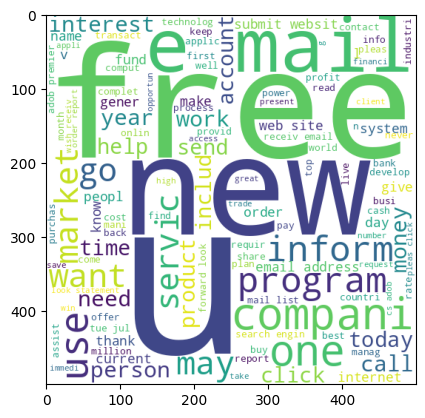

In [70]:
# plt.figure(figsize=(15,6))
plt.imshow(spam_wc)
plt.show()

In [71]:
ham_wc = wc.generate(df[df['target'] == 0]['transformed_text'].str.cat(sep=" "))

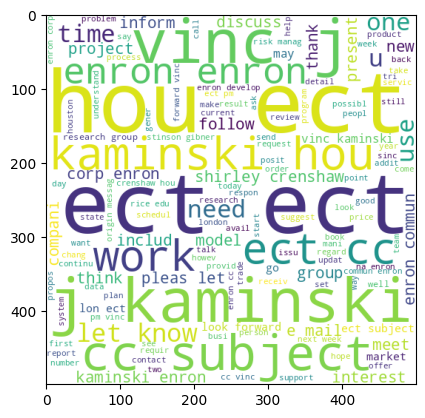

In [72]:
# plt.figure(figsize=(15,6))
plt.imshow(spam_wc)
plt.show()

In [75]:
spam_corpus = []
for email in df[df['target'] == 1]['transformed_text'].tolist():
    for word in email.split():
        spam_corpus.append(word)
len(spam_corpus)

154524

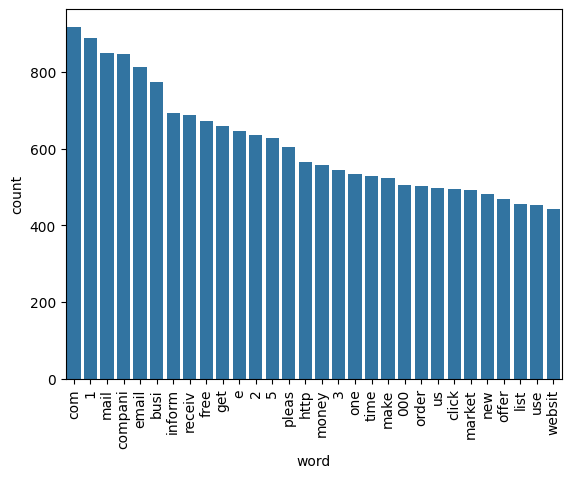

In [85]:
from collections import Counter
sns.barplot(pd.DataFrame(Counter(spam_corpus).most_common(30), columns=['word', 'count']), x='word', y='count')
plt.xticks(rotation='vertical')
plt.show()

In [86]:
ham_corpus = []
for email in df[df['target'] == 0]['transformed_text'].tolist():
    for word in email.split():
        ham_corpus.append(word)
len(ham_corpus)

691545

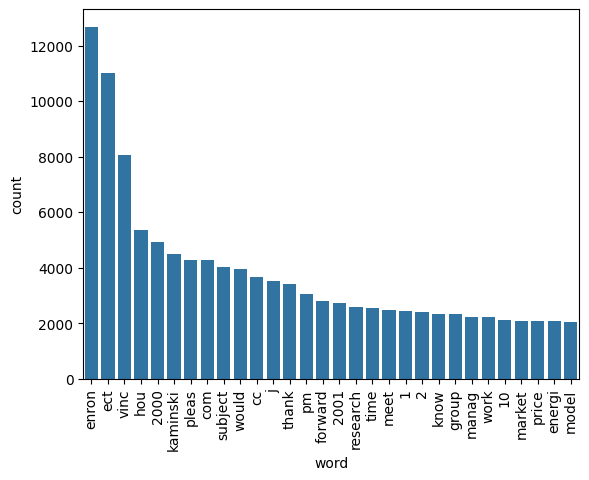

In [87]:
from collections import Counter
sns.barplot(pd.DataFrame(Counter(ham_corpus).most_common(30), columns=['word', 'count']), x='word', y='count')
plt.xticks(rotation='vertical')
plt.show()

### 4. Model Building
* We will use Naive baise as well as Ensemble Methods as text data works good with NB

In [113]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
cv = CountVectorizer()
# tfidf = TfidfVectorizer()
tfidf = TfidfVectorizer(max_features=3000)

In [114]:
# X = cv.fit_transform(df['transformed_text']).toarray()
X = tfidf.fit_transform(df['transformed_text']).toarray()

In [115]:
X.shape

(8207, 3000)

In [116]:
y = df['target'].values

In [117]:
y

array([1, 0, 0, ..., 0, 0, 0], shape=(8207,))

In [118]:
from sklearn.model_selection import train_test_split

In [119]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

In [120]:
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score

In [121]:
gnb = GaussianNB()
mnb = MultinomialNB()
bnb = BernoulliNB()

In [122]:
gnb.fit(X_train, y_train)
y_pred1 = gnb.predict(X_test)
print(accuracy_score(y_test, y_pred1))
print(confusion_matrix(y_test, y_pred1))
print(precision_score(y_test, y_pred1))

0.8045066991473813
[[1009  296]
 [  25  312]]
0.5131578947368421


In [123]:
mnb.fit(X_train, y_train)
y_pred2 = gnb.predict(X_test)
print(accuracy_score(y_test, y_pred2))
print(confusion_matrix(y_test, y_pred2))
print(precision_score(y_test, y_pred2))

0.8045066991473813
[[1009  296]
 [  25  312]]
0.5131578947368421


In [124]:
bnb.fit(X_train, y_train)
y_pred3 = gnb.predict(X_test)
print(accuracy_score(y_test, y_pred3))
print(confusion_matrix(y_test, y_pred3))
print(precision_score(y_test, y_pred3))

0.8045066991473813
[[1009  296]
 [  25  312]]
0.5131578947368421


In [126]:
import pickle

In [127]:
pickle.dump(tfidf, open('models/vectorizer.pkl', 'wb'))
pickle.dump(mnb, open('models/model.pkl', 'wb'))